
A minimal runnable script that:
  * loads/creates placeholder organoid graphs,
  * builds the dataset,
  * trains with the two-phase sparse procedure,
  * prints evaluation metrics and top coefficients,
  * saves history to disk for later plotting.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


In [23]:
from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import load_aux_metadata_for_dir, attach_metadata_to_graphs

# Load all organoids
data_dir = PROJECT_ROOT / "training_data" / "full_set"
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=["graph_path", "seg_path"],
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

Loaded 1224 graphs; skipped 0.
Loaded 1224 organoids.
Attached metadata to 1224/1224 graphs.


In [24]:
# from src.data.metadata import filter_graphs_by_metadata

# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4", "day4p5-more"],
# )

# print(f"After timepoint filter: {len(graphs)} organoids.")

In [25]:
from src.data.metadata import ensure_metadata_keys

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)


complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

mask_keep = (~np.isfinite(complexities)) | (complexities >= 1.0)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]

print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 881 organoids.


In [26]:
from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)


In [27]:
from src.data.metadata import strip_graph_metadata
from src.data.splits import standardize_graph_targets, train_val_split_graphs

graphs = strip_graph_metadata(graphs, inplace=False)


# Split dataset by organoid
g_train, g_val = train_val_split_graphs(graphs, val_frac=0.2, seed=None)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

center, scale = standardize_graph_targets(g_train, g_val, robust=True)

Split -> train: 705 | val: 176


In [28]:
from src.training.loop import TrainConfig, train

cfg = TrainConfig(
    loss_name="gaussian",
    lr=1e-3,
    batch_size=128,
    max_epochs=300,
    patience=30,
    num_workers=4,
)

In [29]:
from src.data.ring_features import attach_precomputed_ring_features

K_MAX = 9


g_train = attach_precomputed_ring_features(
    g_train,
    k_hops=K_MAX,
    inplace=False,
)

g_val = attach_precomputed_ring_features(
    g_val,
    k_hops=K_MAX,
    inplace=False,
)

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

from src.models.gnn import (
    PureSAGECurvature,
    SAGEMaxCurvature,
    GINCurvature,
    GATCurvature,
    JKGraphSAGECurvature,
    count_parameters,
)
from src.models.ring_mlp import RingFractionMLP, PooledKHopMLP
from src.models.io import save_model_checkpoint

SAVE_FLAG = True
scan_name = "scan_depth_multi_all"
save_root = PROJECT_ROOT / "models" / scan_name

depths = np.arange(0, K_MAX)

base_hidden_dim = 64
base_dropout = 0.1
base_norm = "batch"

trained_model_families = {
    "GraphSAGE": [],
    "SageMAX": [],
    "GIN": [],
    "GAT": [],
    "JKsage": [],
    "ring": [],
    "pooled": [],
}

param_rows = []

for family in trained_model_families.keys():
    family_root = save_root / family

    for k in depths:
        print(f"\n=== Training {family} model with depth={k} ===")

        n_markers = int(g_train[0].x.size(1))

        if family == "GraphSAGE":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
            }
            model = PureSAGECurvature(**model_kwargs)

        elif family == "SageMAX":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
            }
            model = SAGEMaxCurvature(**model_kwargs)

        elif family == "GIN":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "train_eps": True,
            }
            model = GINCurvature(**model_kwargs)

        elif family == "GAT":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "heads": 4,
                "attn_dropout": 0.0,
            }
            model = GATCurvature(**model_kwargs)

        elif family == "JKsage":
            model_kwargs = {
                "n_markers": n_markers,
                "hidden_dim": base_hidden_dim,
                "num_layers": int(k),
                "dropout": base_dropout,
                "residual": True,
                "norm": base_norm,
                "jk_mode": "cat",
            }
            model = JKGraphSAGECurvature(**model_kwargs)

        elif family == "ring":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
            }
            model = RingFractionMLP(**model_kwargs)

        elif family == "pooled":
            model_kwargs = {
                "n_markers": n_markers,
                "k_hops": int(k),
                "hidden_dim": base_hidden_dim,
                "dropout": base_dropout,
                "norm": base_norm,
                "feature_attr": "x_ring",
                "include_center": True,
            }
            model = PooledKHopMLP(**model_kwargs)

        else:
            raise ValueError(f"Unknown family: {family}")

        n_params_trainable = count_parameters(model, trainable_only=True)
        n_params_total = count_parameters(model, trainable_only=False)

        param_rows.append({
            "family": family,
            "depth": int(k),
            "model_class": type(model).__name__,
            "n_params_trainable": n_params_trainable,
            "n_params_total": n_params_total,
        })

        print(f"Parameters: trainable={n_params_trainable:,} | total={n_params_total:,}")

        model, metrics, history = train(model, g_train, g_val, cfg)
        trained_model_families[family].append(model)

        if SAVE_FLAG:
            save_path = family_root / f"model_depth_{k}.pt"

            save_model_checkpoint(
                path=save_path,
                model=model,
                optimizer=None,
                epoch=len(history["train_loss"]),
                metrics=metrics,
                config={
                    "model_family": family,
                    "model_class": type(model).__name__,
                    "model_kwargs": model_kwargs,
                    "train_config": vars(cfg),
                    "n_params_trainable": n_params_trainable,
                    "n_params_total": n_params_total,
                },
            )

            print(f"Saved → {save_path}")

param_df = pd.DataFrame(param_rows)
display(param_df)


=== Training GraphSAGE model with depth=0 ===
Parameters: trainable=642 | total=642
epoch 001 | train loss 1.3690 mae 0.9885 | val loss 1.1534 mae 0.9695
epoch 002 | train loss 1.2736 mae 0.9864 | val loss 1.0883 mae 0.9681
epoch 003 | train loss 1.2031 mae 0.9851 | val loss 1.0354 mae 0.9673
epoch 004 | train loss 1.1362 mae 0.9840 | val loss 0.9941 mae 0.9670
epoch 005 | train loss 1.0873 mae 0.9832 | val loss 0.9604 mae 0.9666
epoch 006 | train loss 1.0436 mae 0.9825 | val loss 0.9340 mae 0.9662
epoch 007 | train loss 1.0116 mae 0.9813 | val loss 0.9133 mae 0.9658
epoch 008 | train loss 0.9835 mae 0.9807 | val loss 0.8974 mae 0.9656
epoch 009 | train loss 0.9630 mae 0.9798 | val loss 0.8848 mae 0.9657
epoch 010 | train loss 0.9474 mae 0.9797 | val loss 0.8746 mae 0.9660
epoch 011 | train loss 0.9319 mae 0.9794 | val loss 0.8668 mae 0.9662
epoch 012 | train loss 0.9210 mae 0.9795 | val loss 0.8606 mae 0.9666
epoch 013 | train loss 0.9139 mae 0.9796 | val loss 0.8560 mae 0.9672
epoch

/home/fmoller/miniforge3/envs/organoid-gnn/lib/python3.11/site-packages/torch_geometric/warnings.py:11: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(message)


epoch 001 | train loss 1.1864 mae 0.9990 | val loss 1.0500 mae 0.9764
epoch 002 | train loss 0.8935 mae 0.9711 | val loss 0.8510 mae 0.9519
epoch 003 | train loss 0.8669 mae 0.9607 | val loss 0.8018 mae 0.9389
epoch 004 | train loss 0.8426 mae 0.9629 | val loss 0.7953 mae 0.9397
epoch 005 | train loss 0.8226 mae 0.9616 | val loss 0.7897 mae 0.9388
epoch 006 | train loss 0.8103 mae 0.9558 | val loss 0.7782 mae 0.9352
epoch 007 | train loss 0.8098 mae 0.9477 | val loss 0.7709 mae 0.9334
epoch 008 | train loss 0.8042 mae 0.9429 | val loss 0.7678 mae 0.9354
epoch 009 | train loss 0.7939 mae 0.9442 | val loss 0.7651 mae 0.9390
epoch 010 | train loss 0.7960 mae 0.9456 | val loss 0.7633 mae 0.9430
epoch 011 | train loss 0.7922 mae 0.9473 | val loss 0.7636 mae 0.9432
epoch 012 | train loss 0.7925 mae 0.9463 | val loss 0.7624 mae 0.9373
epoch 013 | train loss 0.7884 mae 0.9415 | val loss 0.7605 mae 0.9330
epoch 014 | train loss 0.7858 mae 0.9390 | val loss 0.7585 mae 0.9340
epoch 015 | train lo

,family,depth,model_class,n_params_trainable,n_params_total
0,GraphSAGE,0,PureSAGECurvature,642,642
1,GraphSAGE,1,PureSAGECurvature,5826,5826
2,GraphSAGE,2,PureSAGECurvature,14210,14210
3,GraphSAGE,3,PureSAGECurvature,22594,22594
4,GraphSAGE,4,PureSAGECurvature,30978,30978
...,...,...,...,...,...
58,pooled,4,PooledKHopMLP,4930,4930
59,pooled,5,PooledKHopMLP,4930,4930
60,pooled,6,PooledKHopMLP,4930,4930
61,pooled,7,PooledKHopMLP,4930,4930


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.inference.predict import predict_targets
from src.analysis.marker_stats import compute_markerwise_residuals, estimate_marker_conditional_gaussians
from src.analysis.prediction_analysis import rescale_distribution_outputs , compute_markerwise_uncertainty_correlation, compute_global_uncertainty_correlation
from src.data.metadata import load_marker_names_from_dir

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
marker_names = load_marker_names_from_dir(str(data_dir))


def compute_nodewise_nll(y, mu, var, eps=1e-12):
    y = np.asarray(y, dtype=np.float64)
    mu = np.asarray(mu, dtype=np.float64)
    var = np.asarray(var, dtype=np.float64)
    var = np.maximum(var, eps)
    return 0.5 * (np.log(var) + (y - mu) ** 2 / var)


def compute_markerwise_nll(y_true, mu_model, log_var_model, X, eps=1e-12):
    y_true = np.asarray(y_true, dtype=np.float64).reshape(-1)
    mu_model = np.asarray(mu_model, dtype=np.float64).reshape(-1)
    log_var_model = np.asarray(log_var_model, dtype=np.float64).reshape(-1)
    X = np.asarray(X)

    M = X.shape[1]
    n_pos = np.zeros(M, dtype=np.int64)

    mu_pos, var_pos, mu_none, var_none = estimate_marker_conditional_gaussians(y_true, X)

    var_pos = np.asarray(var_pos, dtype=np.float64)
    var_pos = np.maximum(var_pos, eps)

    var_model = np.exp(log_var_model).astype(np.float64)
    var_model = np.maximum(var_model, eps)

    nll_model_list, nll_base_list = [], []
    Delta_mean_list, Delta_var_list = [], []

    for m in range(M):
        mask = X[:, m] > 0.5
        n = int(np.sum(mask))
        n_pos[m] = n

        if n == 0:
            nll_model_list.append(np.zeros((0,), dtype=np.float64))
            nll_base_list.append(np.zeros((0,), dtype=np.float64))
            Delta_mean_list.append(np.zeros((0,), dtype=np.float64))
            Delta_var_list.append(np.zeros((0,), dtype=np.float64))
            continue

        y_m = y_true[mask]
        mu_m = mu_model[mask]
        var_m = var_model[mask]

        mu_b = float(mu_pos[m])
        var_b = float(var_pos[m])

        nll_m = compute_nodewise_nll(y_m, mu_m, var_m).astype(np.float64)
        nll_b = compute_nodewise_nll(y_m, mu_b, var_b).astype(np.float64)

        nll_model_list.append(nll_m)
        nll_base_list.append(nll_b)

        Delta_var = 0.5 * np.log(var_b / var_m)
        Delta_mean = 0.5 * ((y_m - mu_b) ** 2 / var_b - (y_m - mu_m) ** 2 / var_m)

        Delta_mean_list.append(Delta_mean.astype(np.float64))
        Delta_var_list.append(Delta_var.astype(np.float64))

    return nll_model_list, nll_base_list, Delta_mean_list, Delta_var_list, n_pos


def eval_model_per_marker(model, g_val, device, scale, center, eps=1e-12):
    y, mu, log_var, X = predict_targets(
        g_val,
        model,
        device=device,
        return_log_var=True,
    )

    y, mu, log_var = rescale_distribution_outputs(
        y, mu, log_var=log_var, center=center, scale=scale
    )
    var = np.exp(log_var)

    residuals_model, residuals_base, n_pos_resid, mu_pos_resid = compute_markerwise_residuals(y, mu, X)

    mse_model = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_model])
    mse_base = np.array([np.mean(r**2) if r.size > 0 else np.nan for r in residuals_base])

    sem_mse_model = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_model
    ])
    sem_mse_base = np.array([
        np.std(r**2, ddof=1) / np.sqrt(r.size) if r.size > 1 else np.nan
        for r in residuals_base
    ])

    Xb = X > 0.5
    var_model = np.array([
        np.mean(var[Xb[:, m]]) if np.any(Xb[:, m]) else np.nan
        for m in range(X.shape[1])
    ])
    sem_var_model = np.array([
        np.std(var[Xb[:, m]], ddof=1) / np.sqrt(np.sum(Xb[:, m]))
        if np.sum(Xb[:, m]) > 1 else np.nan
        for m in range(X.shape[1])
    ])

    var_base = mse_base
    sem_var_base = sem_mse_base

    nll_model_list, nll_base_list, delta_mean_list, delta_var_list, n_pos_nll = compute_markerwise_nll(
        y_true=y,
        mu_model=mu,
        log_var_model=log_var,
        X=X,
        eps=eps,
    )

    nll_model = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_model_list])
    nll_base = np.array([np.mean(v) if v.size > 0 else np.nan for v in nll_base_list])

    sem_nll_model = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_model_list
    ])
    sem_nll_base = np.array([
        np.std(v, ddof=1) / np.sqrt(v.size) if v.size > 1 else np.nan
        for v in nll_base_list
    ])

    delta_mean = np.array([np.mean(v) if v.size > 0 else np.nan for v in delta_mean_list])
    delta_var = np.array([np.mean(v) if v.size > 0 else np.nan for v in delta_var_list])

    # --- uncertainty / squared-residual correlation ---
    rho_marker, pval_marker, n_pos_corr = compute_markerwise_uncertainty_correlation(
        y=y,
        mu=mu,
        log_var=log_var,
        X=X,
    )

    rho_global, pval_global = compute_global_uncertainty_correlation(
        y=y,
        mu=mu,
        log_var=log_var,
    )

    return {
        "mse_model": mse_model,
        "sem_mse_model": sem_mse_model,
        "mse_base": mse_base,
        "sem_mse_base": sem_mse_base,
        "var_model": var_model,
        "sem_var_model": sem_var_model,
        "var_base": var_base,
        "sem_var_base": sem_var_base,
        "nll_model": nll_model,
        "sem_nll_model": sem_nll_model,
        "nll_base": nll_base,
        "sem_nll_base": sem_nll_base,
        "delta_mean": delta_mean,
        "delta_var": delta_var,
        "rho_marker": rho_marker,
        "pval_marker": pval_marker,
        "n_pos_corr": n_pos_corr,
        "rho_global": rho_global,
        "pval_global": pval_global,
    }


depths = np.asarray(depths)

all_results = {}

for family, models in trained_model_families.items():
    fam_mse_model = []
    fam_sem_mse_model = []
    fam_var_model = []
    fam_sem_var_model = []
    fam_nll_model = []
    fam_sem_nll_model = []
    fam_rho_marker = []
    fam_pval_marker = []
    fam_n_pos_corr = []
    fam_rho_global = []
    fam_pval_global = []

    fam_mse_base = None
    fam_var_base = None
    fam_sem_mse_base = None
    fam_nll_base = None
    fam_sem_nll_base = None

    for model in models:
        model.eval()
        out = eval_model_per_marker(model, g_val, device, scale, center)

        fam_mse_model.append(out["mse_model"])
        fam_sem_mse_model.append(out["sem_mse_model"])
        fam_var_model.append(out["var_model"])
        fam_sem_var_model.append(out["sem_var_model"])
        fam_nll_model.append(out["nll_model"])
        fam_sem_nll_model.append(out["sem_nll_model"])
        fam_rho_marker.append(out["rho_marker"])
        fam_pval_marker.append(out["pval_marker"])
        fam_n_pos_corr.append(out["n_pos_corr"])
        fam_rho_global.append(out["rho_global"])
        fam_pval_global.append(out["pval_global"])

        if fam_mse_base is None:
            fam_mse_base = out["mse_base"]
            fam_var_base = out["var_base"]
            fam_sem_mse_base = out["sem_mse_base"]
            fam_nll_base = out["nll_base"]
            fam_sem_nll_base = out["sem_nll_base"]

    all_results[family] = {
        "mse_model": np.stack(fam_mse_model, axis=0),
        "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
        "var_model": np.stack(fam_var_model, axis=0),
        "sem_var_model": np.stack(fam_sem_var_model, axis=0),
        "nll_model": np.stack(fam_nll_model, axis=0),
        "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
        "rho_marker": np.stack(fam_rho_marker, axis=0),
        "pval_marker": np.stack(fam_pval_marker, axis=0),
        "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
        "rho_global": np.asarray(fam_rho_global, dtype=float),
        "pval_global": np.asarray(fam_pval_global, dtype=float),
        "mse_base": fam_mse_base,
        "var_base": fam_var_base,
        "sem_mse_base": fam_sem_mse_base,
        "nll_base": fam_nll_base,
        "sem_nll_base": fam_sem_nll_base,
    }

In [40]:
# ---- choose markers to plot ----
marker_names = load_marker_names_from_dir(str(data_dir))


print(marker_names)

selected_marker_names = marker_names # <-- change to your markers
name_to_idx = {n: i for i, n in enumerate(marker_names)}
selected_idx = [name_to_idx[n] for n in selected_marker_names]


DEFAULT_MARKER_COLORS = {
    "Agr2": "#359BD5",
    "Lysozyme": "#2C75D2",
    "Mucin 2": "#3EC1D9",
    "Chroma": "#D852CB",
    "Glucagon": "#983EE2",
    "Serotonin": "#F392E3",
    "LGR5": "#FFB431",
    "AldoB": "#F16C6A",
    "Cyclin D": "#808080",
    "Cyclin A": "#808080",
    "KI67": "#808080",
    "other": "#EBEBEB",
}

baseline_color = "#888888"

def get_marker_color(name):
    return DEFAULT_MARKER_COLORS.get(name, DEFAULT_MARKER_COLORS["other"])

['LGR5', 'Chroma', 'AldoB', 'Agr2', 'Serotonin', 'Lysozyme', 'KI67']


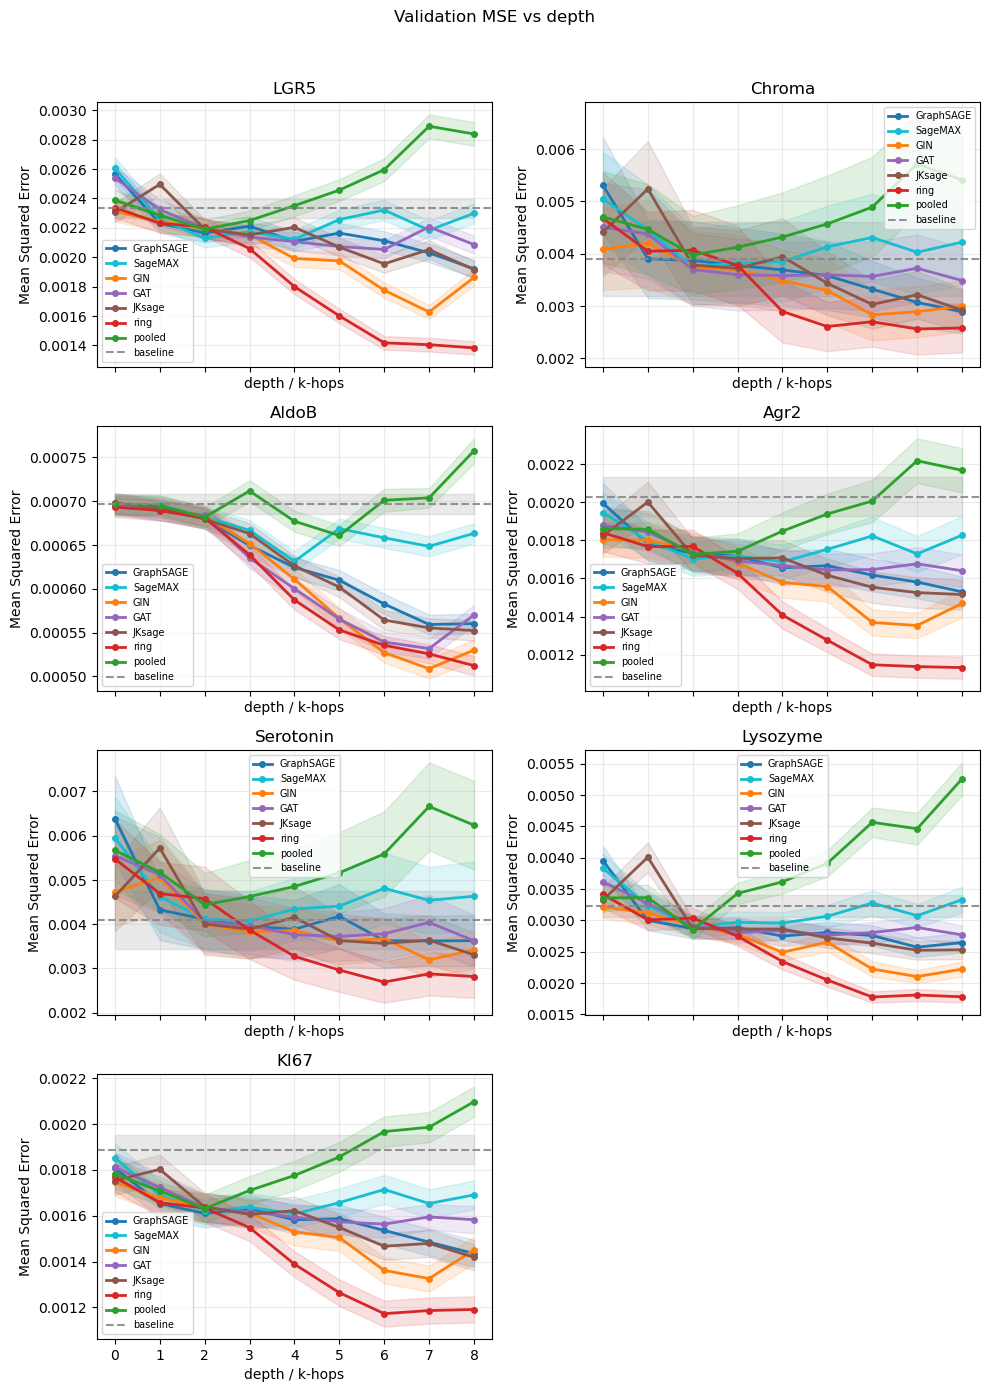

In [41]:
import math
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_colors = {
    "GraphSAGE": "#1f77b4",
    "SageMAX":   "#17becf",
    "GIN":       "#ff7f0e",
    "GAT":       "#9467bd",
    "JKsage":    "#8c564b",
    "ring":      "#d62728",
    "pooled":    "#2ca02c",
}

family_order = [
    "GraphSAGE",
    "SageMAX",
    "GIN",
    "GAT",
    "JKsage",
    "ring",
    "pooled",
]

baseline_color = "#888888"

n_sel = len(selected_idx)
n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["mse_model"][:, mi]
        s = all_results[family]["sem_mse_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    # baseline is shared across families, so just take the first available one
    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["mse_base"][mi]
    s0 = all_results[ref_family]["sem_mse_base"][mi]

    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )
    ax.fill_between(
        depths,
        y0 - s0,
        y0 + s0,
        color=baseline_color,
        alpha=0.18,
    )

    ax.set_title(mname)
    ax.set_ylabel("Mean Squared Error")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Validation MSE vs depth", y=1.02)
plt.tight_layout()
plt.show()

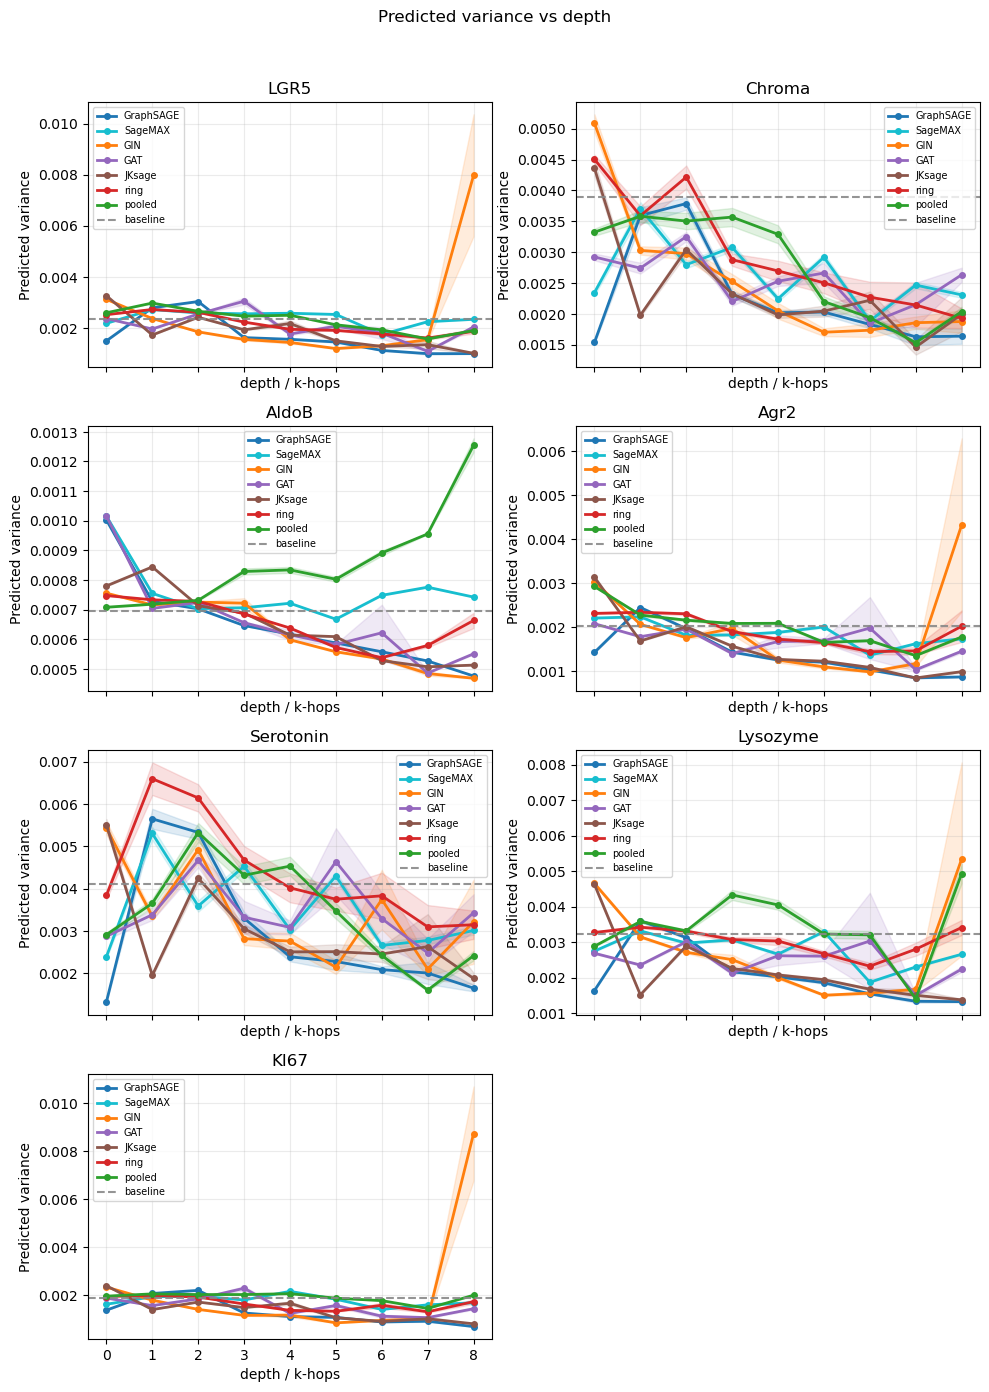

In [42]:
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["var_model"][:, mi]
        s = all_results[family]["sem_var_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["var_base"][mi]
    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )

    ax.set_title(mname)
    ax.set_ylabel("Predicted variance")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Predicted variance vs depth", y=1.02)
plt.tight_layout()
plt.show()

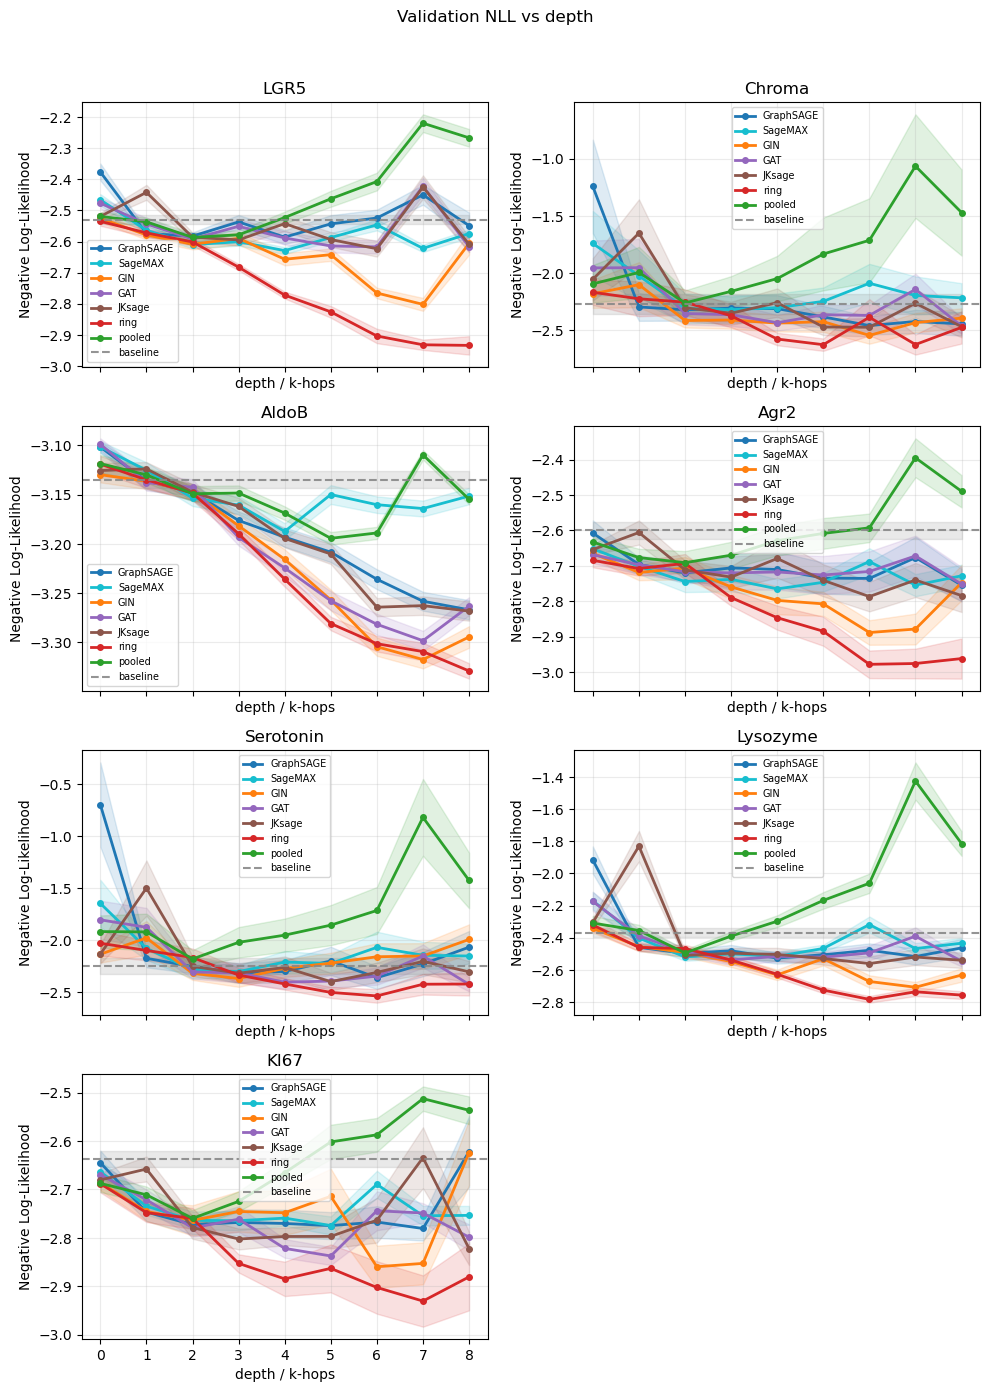

In [43]:
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["nll_model"][:, mi]
        s = all_results[family]["sem_nll_model"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )
        ax.fill_between(
            x,
            y - s,
            y + s,
            color=family_colors[family],
            alpha=0.14,
        )

    ref_family = next(f for f in family_order if f in all_results)
    y0 = all_results[ref_family]["nll_base"][mi]
    s0 = all_results[ref_family]["sem_nll_base"][mi]

    ax.axhline(
        y0,
        linestyle="--",
        color=baseline_color,
        alpha=0.9,
        label="baseline",
    )
    ax.fill_between(
        depths,
        y0 - s0,
        y0 + s0,
        color=baseline_color,
        alpha=0.18,
    )

    ax.set_title(mname)
    ax.set_ylabel("Negative Log-Likelihood")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Validation NLL vs depth", y=1.02)
plt.tight_layout()
plt.show()

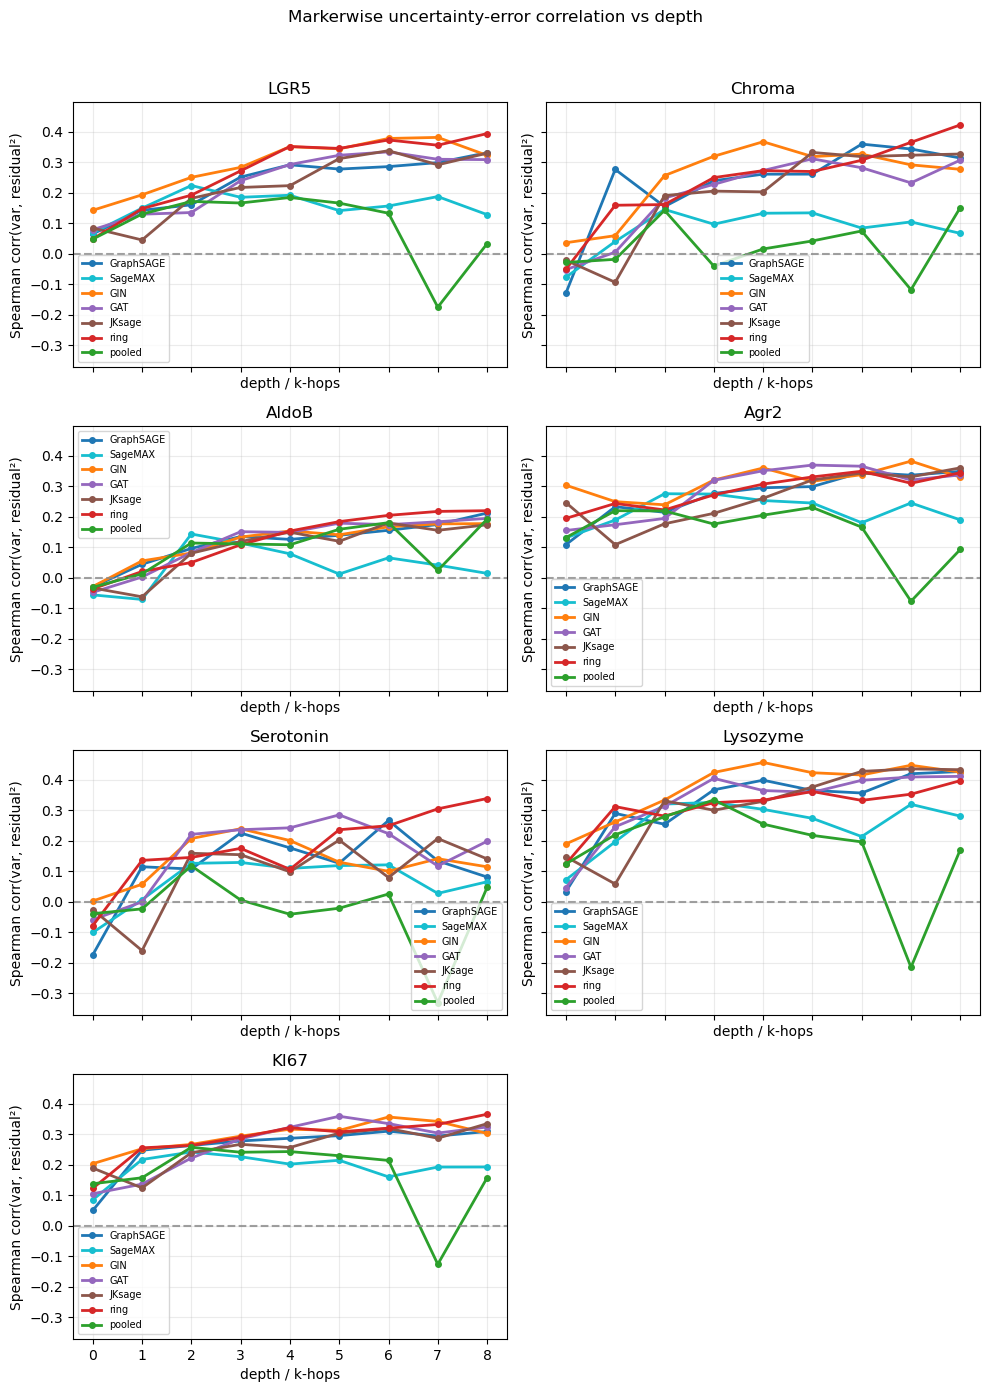

In [44]:
import math

n_sel = len(selected_idx)
n_cols = 2
n_rows = math.ceil(n_sel / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 3.4 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

for ax, mi, mname in zip(axes, selected_idx, selected_marker_names):
    for family in family_order:
        if family not in all_results:
            continue

        y = all_results[family]["rho_marker"][:, mi]
        x = depths

        ax.plot(
            x, y, "-o",
            linewidth=2,
            markersize=4,
            color=family_colors[family],
            label=family,
        )

    ax.axhline(0.0, linestyle="--", color="#888888", alpha=0.8)

    ax.set_title(mname)
    ax.set_ylabel("Spearman corr(var, residual²)")
    ax.set_xlabel("depth / k-hops")
    ax.set_xticks(depths)
    ax.legend(fontsize=7)

for ax in axes[n_sel:]:
    ax.set_visible(False)

fig.suptitle("Markerwise uncertainty-error correlation vs depth", y=1.02)
plt.tight_layout()
plt.show()

In [45]:
for family in family_order:
    if family not in all_results:
        continue
    print(f"\n{family}")
    for d, rho, p in zip(depths, all_results[family]["rho_global"], all_results[family]["pval_global"]):
        print(f"depth={int(d):2d}  rho_global={rho: .3f}  p={p: .2e}")


GraphSAGE
depth= 0  rho_global= 0.007  p= 4.00e-02
depth= 1  rho_global= 0.167  p= 0.00e+00
depth= 2  rho_global= 0.170  p= 0.00e+00
depth= 3  rho_global= 0.218  p= 0.00e+00
depth= 4  rho_global= 0.241  p= 0.00e+00
depth= 5  rho_global= 0.236  p= 0.00e+00
depth= 6  rho_global= 0.266  p= 0.00e+00
depth= 7  rho_global= 0.251  p= 0.00e+00
depth= 8  rho_global= 0.278  p= 0.00e+00

SageMAX
depth= 0  rho_global= 0.047  p= 4.87e-39
depth= 1  rho_global= 0.107  p= 6.30e-192
depth= 2  rho_global= 0.180  p= 0.00e+00
depth= 3  rho_global= 0.173  p= 0.00e+00
depth= 4  rho_global= 0.178  p= 0.00e+00
depth= 5  rho_global= 0.121  p= 1.76e-244
depth= 6  rho_global= 0.130  p= 3.10e-283
depth= 7  rho_global= 0.150  p= 0.00e+00
depth= 8  rho_global= 0.113  p= 8.98e-215

GIN
depth= 0  rho_global= 0.116  p= 2.50e-226
depth= 1  rho_global= 0.151  p= 0.00e+00
depth= 2  rho_global= 0.173  p= 0.00e+00
depth= 3  rho_global= 0.231  p= 0.00e+00
depth= 4  rho_global= 0.264  p= 0.00e+00
depth= 5  rho_global= 0.261